In [1]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

# Lotka-Volterra

In [2]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
true_coeffs = generate_lotka_volterra_true_coefficients(*default_params['lotka_volterra'])

x0s = [(10, 5), (5, 10), (10, 10), (5, 5), (1, 1), (2, 2), (3, 3), (7, 7)]
thresholds = np.logspace(-3, -0.5, 11).tolist()

t_span = (0, 50)

experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
    'np_seed': 0,
    'true_coeffs': true_coeffs,
    # define parameters that can be lists
    'x0': x0s, 'noise_level': 0.01,
    't_eval_train': None, 'dt_train': 0.01, 't_span_train': t_span,
    'train_interpolation_dt': None,
    'threshold': thresholds, 'poly_order': 5, 'n_frequencies': 0
}

results = run_experiment(experiment_config)

rows are x0. there are 8 rows.
columns are threshold. there are 11 columns.
step 1 of 8


100%|██████████| 11/11 [00:04<00:00,  2.47it/s]


step 2 of 8


100%|██████████| 11/11 [00:05<00:00,  1.90it/s]


step 3 of 8


...

100%|██████████| 11/11 [00:04<00:00,  2.39it/s]


step 7 of 8


100%|██████████| 11/11 [00:05<00:00,  2.01it/s]


step 8 of 8


100%|██████████| 11/11 [00:04<00:00,  2.46it/s]


rows are x0. there are 8 rows.
columns are threshold. there are 11 columns.


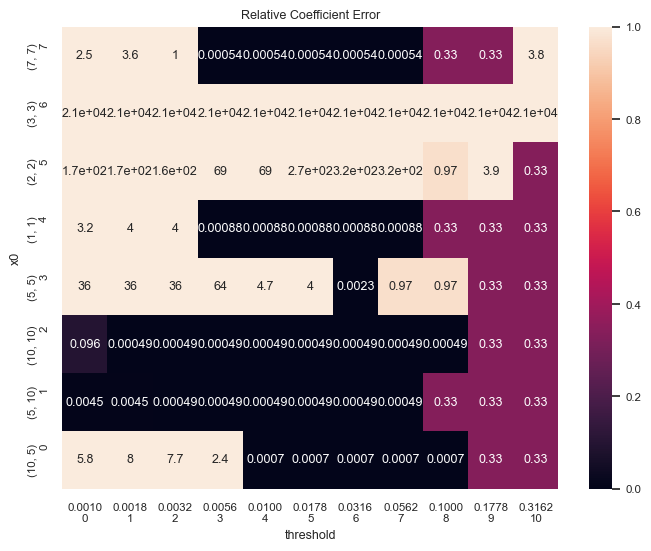

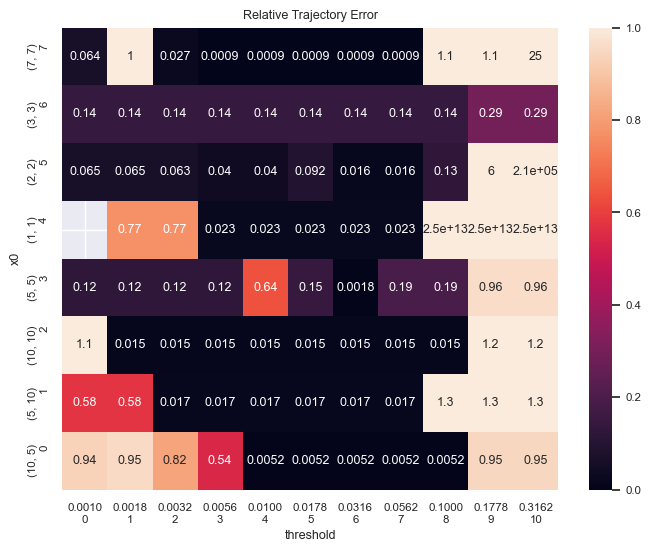

In [3]:
plot_heatmaps(experiment_config, results)

x0' = + 1.09924 x0 + -0.39965 x0 x1 
x1' = + -0.39932 x1 + 0.09979 x0 x1 


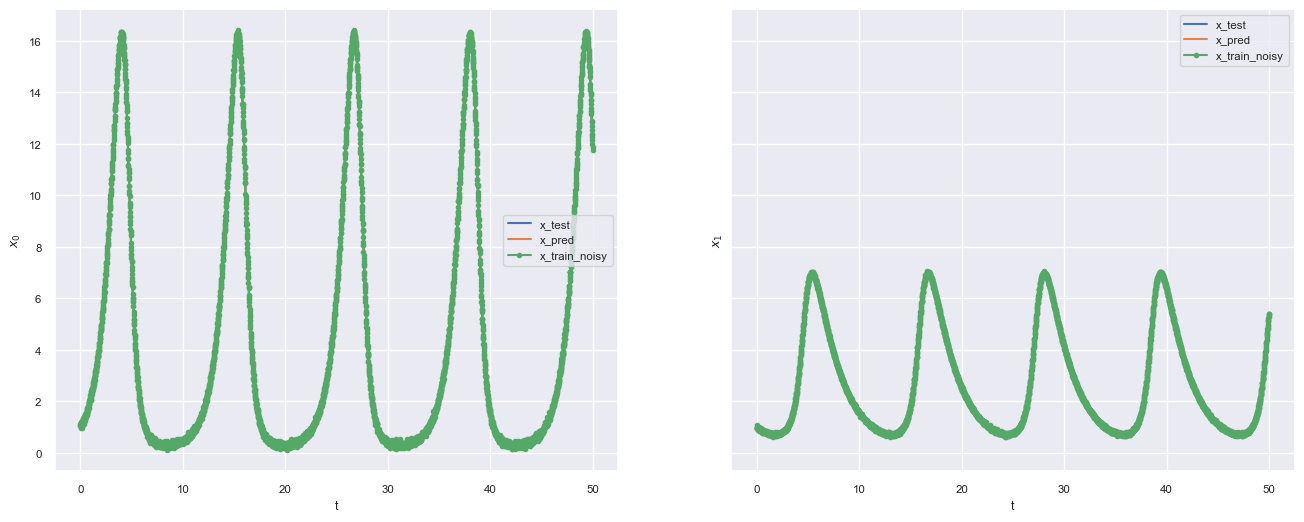

In [5]:
display_single_result(experiment_config, results, 6, 4, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])